The ipynb version of the initial examples, including the outputs.

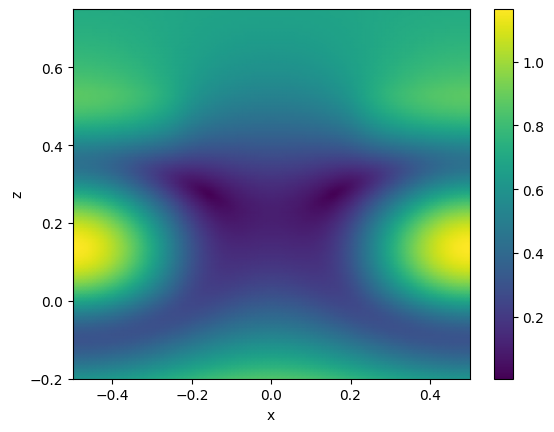

In [11]:
#!/usr/bin/python3
# -*- coding: utf-8 -*-

"""
Dielectric array, with permittivity 12.
Period is 1
Each rod has side length 0.55.

 → x
↓z    ___     ___
...  |   |   |   |  ...
      ¯¯¯     ¯¯¯
"""

from inkstone import Inkstone
import numpy as np

s = Inkstone()
s.lattice = 1
s.num_g = 30
s.frequency = 0.4

s.AddMaterial(name='di', epsilon=12)

s.AddLayer(name='in', thickness=0, material_background='vacuum')
d = 0.55
s.AddLayer(name='slab', thickness=d, material_background='di')
s.AddLayerCopy(name='out', original_layer='in', thickness=0)

s.AddPattern1D(layer='slab', pattern_name='box', material='vacuum', width=0.45, center=0)

s.SetExcitation(theta=0., phi=0., s_amplitude=1, p_amplitude=0)


Ex, Ey, Ez, Hx, Hy, Hz = s.GetFields(xmin=-0.5, xmax=0.5, nx=101,
                                     y=0,
                                     zmin=-0.2, zmax=d+0.2, nz=101)

#%% plotting
from matplotlib import pyplot as plt
plt.pcolormesh(np.linspace(-0.5, 0.5, 101),
               np.linspace(-0.2, d+0.2, 101),
               np.abs(Ey[0, :, :]).T,
               shading='gouraud')
plt.xlabel('x')
plt.ylabel('z')
plt.colorbar()

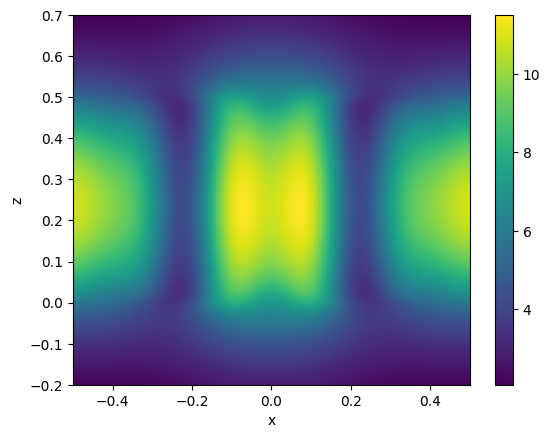

In [8]:
#!/usr/bin/python3
# -*- coding: utf-8 -*-

"""
A photonic-crystal slab in vacuum. Permittivity 12.
Square lattice with period 1 in both x and y.
thickness 0.5
A circular hole of radius 0.2 in each unit cell.

 → y
↓x      ⋮
     ◯ ◯ ◯
...  ◯ ◯ ◯ ...  (top view)
     ◯ ◯ ◯
        ⋮
"""

import numpy as np
from inkstone import Inkstone

s = Inkstone()
s.lattice = ((1, 0), (0, 1))
s.num_g = 100

s.AddMaterial(name='di', epsilon=12)

s.AddLayer(name='in', thickness=0, material_background='vacuum')
s.AddLayer(name='slab', thickness=0.5, material_background='di')
s.AddLayerCopy(name='out', original_layer='in', thickness=0)

s.AddPatternDisk(layer='slab', pattern_name='disk', material='vacuum', radius=0.2)

# Incident wave
s.SetExcitation(theta=0, phi=0, s_amplitude=0, p_amplitude=1)

s.frequency = 0.38

Ex, Ey, Ez, Hx, Hy, Hz = s.GetFields(xmin=-0.5, xmax=0.5, nx=101,
                                     y=0,
                                     zmin=-0.2, zmax=0.7, nz=91)

#%% plotting
from matplotlib import pyplot as plt

plt.pcolormesh(np.linspace(-0.5, 0.5, 101),
               np.linspace(-0.2, 0.7, 91),
               np.abs(Ex[0, :, :]).T, shading='gouraud')
plt.xlabel('x')
plt.ylabel('z')
plt.colorbar()


frequency: 0.2
frequency: 0.2035
frequency: 0.207
frequency: 0.2105
frequency: 0.214
frequency: 0.2175
frequency: 0.221
frequency: 0.2245
frequency: 0.228
frequency: 0.2315
frequency: 0.235
frequency: 0.2385
frequency: 0.242
frequency: 0.2455
frequency: 0.249
frequency: 0.2525
frequency: 0.256
frequency: 0.2595
frequency: 0.263
frequency: 0.2665
frequency: 0.27
frequency: 0.2735
frequency: 0.277
frequency: 0.2805
frequency: 0.284
frequency: 0.2875
frequency: 0.291
frequency: 0.2945
frequency: 0.298
frequency: 0.3015
frequency: 0.305
frequency: 0.3085
frequency: 0.312
frequency: 0.3155
frequency: 0.319
frequency: 0.3225
frequency: 0.326
frequency: 0.3295
frequency: 0.333
frequency: 0.3365
frequency: 0.34
frequency: 0.3435
frequency: 0.347
frequency: 0.3505
frequency: 0.354
frequency: 0.3575
frequency: 0.361
frequency: 0.3645
frequency: 0.368
frequency: 0.3715
frequency: 0.375
frequency: 0.3785
frequency: 0.382
frequency: 0.3855
frequency: 0.389
frequency: 0.3925
frequency: 0.396
frequen

Text(0, 0.5, 'transmission')

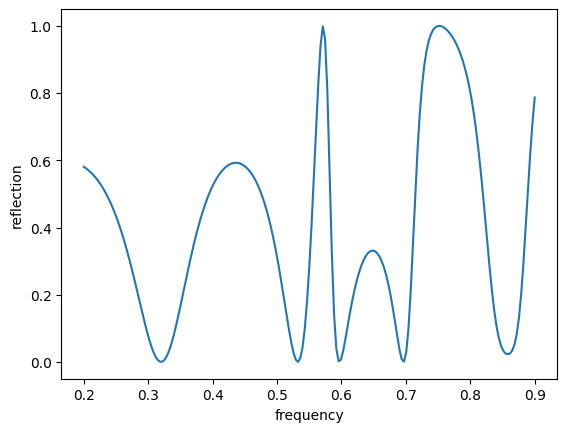

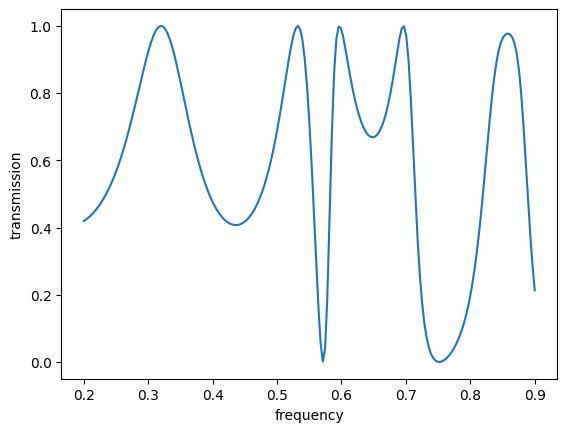

In [12]:
#!/usr/bin/python3
# -*- coding: utf-8 -*-

"""
Dielectric array, with permittivity 12.
Period is 1
Each rod has side length 0.55.

 → x
↓z    ___     ___
...  |   |   |   |  ...  (side view)
      ¯¯¯     ¯¯¯
"""

from inkstone import Inkstone
import numpy as np

s = Inkstone()
s.lattice = 1
s.num_g = 30

s.AddMaterial(name='di', epsilon=12)

s.AddLayer(name='in', thickness=0, material_background='vacuum')
d = 0.55
s.AddLayer(name='slab', thickness=d, material_background='di')
s.AddLayerCopy(name='out', original_layer='in', thickness=0)

s.AddPattern1D(layer='slab', pattern_name='box', material='vacuum', width=0.45, center=0.5)

s.SetExcitation(theta=0, phi=0, s_amplitude=1, p_amplitude=0)

I = []
R = []
T = []
freq = np.linspace(0.2, 0.9, 201)
for f in freq:
    s.frequency = f
    i, r = s.GetPowerFlux('in')
    I.append(i)
    R.append(-r / i)
    T.append(s.GetPowerFlux('out')[0] / i)
    print("frequency: {:g}".format(f))

#%% plotting
from matplotlib import pyplot as plt

plt.figure()
plt.plot(freq, R)
plt.xlabel('frequency')
plt.ylabel('reflection')
plt.figure()
plt.plot(freq, T)
plt.xlabel('frequency')
plt.ylabel('transmission')

Frequency: 0.25
Frequency: 0.251
Frequency: 0.252
Frequency: 0.253
Frequency: 0.254
Frequency: 0.255
Frequency: 0.256
Frequency: 0.257
Frequency: 0.258
Frequency: 0.259
Frequency: 0.26
Frequency: 0.261
Frequency: 0.262
Frequency: 0.263
Frequency: 0.264
Frequency: 0.265
Frequency: 0.266
Frequency: 0.267
Frequency: 0.268
Frequency: 0.269
Frequency: 0.27
Frequency: 0.271
Frequency: 0.272
Frequency: 0.273
Frequency: 0.274
Frequency: 0.275
Frequency: 0.276
Frequency: 0.277
Frequency: 0.278
Frequency: 0.279
Frequency: 0.28
Frequency: 0.281
Frequency: 0.282
Frequency: 0.283
Frequency: 0.284
Frequency: 0.285
Frequency: 0.286
Frequency: 0.287
Frequency: 0.288
Frequency: 0.289
Frequency: 0.29
Frequency: 0.291
Frequency: 0.292
Frequency: 0.293
Frequency: 0.294
Frequency: 0.295
Frequency: 0.296
Frequency: 0.297
Frequency: 0.298
Frequency: 0.299
Frequency: 0.3
Frequency: 0.301
Frequency: 0.302
Frequency: 0.303
Frequency: 0.304
Frequency: 0.305
Frequency: 0.306
Frequency: 0.307
Frequency: 0.308
Freq

Text(0, 0.5, 'transmission')

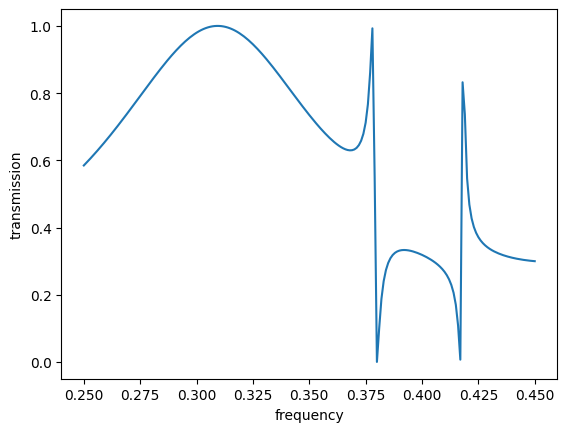

In [13]:
#!/usr/bin/python3
# -*- coding: utf-8 -*-

"""
A photonic-crystal slab in vacuum. Permittivity 12.
Square lattice with period 1 in both x and y.
thickness 0.5
A circular hole of radius 0.2 in each unit cell.

 → y
↓x      ⋮
     ◯ ◯ ◯
...  ◯ ◯ ◯ ...  (top view)
     ◯ ◯ ◯
        ⋮
"""

import numpy as np
from inkstone import Inkstone

s = Inkstone()
s.lattice = ((1, 0), (0, 1))
s.num_g = 50

s.AddMaterial(name='di', epsilon=12)

s.AddLayer(name='in', thickness=0, material_background='vacuum')
s.AddLayer(name='slab', thickness=0.5, material_background='di')
s.AddLayerCopy(name='out', original_layer='in', thickness=0)

s.AddPatternDisk(layer='slab', pattern_name='disk', material='vacuum', radius=0.2)

# Incident wave
s.SetExcitation(theta=0, phi=0, s_amplitude=1, p_amplitude=0)

flux_in = []
flux_out = []
freq = np.linspace(0.25, 0.45, 201)
for i in freq:
    print('Frequency: {:g}'.format(i))

    s.SetFrequency(i)

    flux_in.append(s.GetPowerFlux('in'))
    flux_out.append(s.GetPowerFlux('out'))

incident = np.array([a[0] for a in flux_in])
reflection = -np.array([a[1] for a in flux_in]) / incident
transmission = np.array([a[0] for a in flux_out]) / incident

#%% plotting
from matplotlib import pyplot as plt
plt.plot(freq, transmission)
plt.xlabel('frequency')
plt.ylabel('transmission')